<a href="https://colab.research.google.com/github/Luca-1221/MyMIS433/blob/main/Copy_of_relational_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relational Data

In data analysis, you often need to combine multiple data sets to answer the questions that you are interested in.

Collectively, multiple related sets (tables) of data are called relational data. In relational (SQL) databases (DBs), each table is called a relation. Two tables (relations) may have a relationship between each other via a PK (primary key) and a FK (foreign key). It is also not uncommon to have more than two tables related to each other.

To work with relational data, we typically need to perform three families of operations:
- **Mutating joins**, which add new variables to one data frame from matching observations in another.
- **Filtering joins**, which filter observations from one data frame based on whether or not they match an observation in the other table.
- **Set operations**, which treat observations as if they were set elements.

If you have learned relational databases and SQL (Structured Query Language), you should find many of these concepts and operations familiar.

We will use the **nycflights13** package to learn about relational data.

In [3]:
import pandas as pd
!pip install nycflights13
# Install the "nycflights13" package before you run the following code.
from nycflights13 import flights
from nycflights13 import airlines
from nycflights13 import airports
from nycflights13 import planes
from nycflights13 import weather

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for nycflights13: filename=nycflights13-0.0.3-py3-none-any.whl size=8732722 sha256=dfe24f5d3283f3e51cee57b3d809c56f27175c433ad03b303998abdc48b71f06
  Stored in directory: /root/.cache/pip/wheels/58/ee/20/7838832df5510701439239ec10c2d8927de32aac2729ce2085
Successfully built nycflights13


In [4]:
flights.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


In [5]:
airlines.head()

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.


In [6]:
airports.head()

,faa,name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago
2,06C,Schaumburg Regional,41.989341,-88.101243,801,-6,A,America/Chicago
3,06N,Randall Airport,41.431912,-74.391561,523,-5,A,America/New_York
4,09J,Jekyll Island Airport,31.074472,-81.427778,11,-5,A,America/New_York


In [7]:
planes.head()

,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
0,N10156,2004.0,Fixed wing multi engine,EMBRAER,EMB-145XR,2,55,NaN,Turbo-fan
1,N102UW,1998.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
2,N103US,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
3,N104UW,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
4,N10575,2002.0,Fixed wing multi engine,EMBRAER,EMB-145LR,2,55,NaN,Turbo-fan


In [8]:
weather.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


The relationships between these tables are shown in the following diagram:

In [ ]:
from IPython.display import Image
Image('https://d33wubrfki0l68.cloudfront.net/245292d1ea724f6c3fd8a92063dcd7bfb9758d02/5751b/diagrams/relational-nycflights.png')

For nycflights13:

- ``flights`` connects to ``planes`` via a single variable, ``tailnum``.
- ``flights`` connects to ``airlines`` through the ``carrier`` variable.
- ``flights`` connects to ``airports`` in two ways: via the ``origin`` and ``dest`` variables.
- ``flights`` connects to ``weather`` via origin (the location), and ``year``, ``month``, ``day`` and ``hour`` (the time).

## Keys

The variables used to connect each pair of tables are called **keys**. A key is a variable (or set of variables) that uniquely identifies an observation.

For example, each plane is uniquely identified by its ``tailnum``. In other cases, multiple variables may be needed. For example, to identify an observation in weather you need five variables: ``year``, ``month``, ``day``, ``hour``, and ``origin``.

There are two types of keys:
- A primary key uniquely identifies an observation in its own table. For example, in the ``planes`` table, ``tailnum`` is a primary key because it uniquely identifies each plane in the ``planes`` table.
- A foreign key uniquely identifies an observation in another table. For example, in the ``flights`` table, ``tailnum`` is a foreign key because it matches each flight to a unique plane.

Once you've identified the primary keys in your tables, it is good practice to verify that they do indeed uniquely identify each observation.

In [10]:
from numpy._core.defchararray import count
# Count the number of rows in the table "planes"
len(planes)

3322

In [15]:
# Count the number of unique values in column "tailnum"
planes.tailnum.nunique()

3322

In [16]:
# Count the occurrence of different values in column "tailnum"
planes.tailnum.value_counts()

,count
tailnum,
N999DN,1
N10156,1
N102UW,1
N103US,1
N104UW,1
...,...
N11119,1
N11113,1
N11109,1


In [20]:
# Try to determine the key for flights: ['year','month','day','carrier','flight']?

key_columns = ['year','month','day','carrier','flight', 'dep_time']
num_rows = len(flights)
num_unique_combinations = flights[key_columns].drop_duplicates().shape[0]

print(f"Number of rows in flights: {num_rows}")
print(f"Number of unique combinations for {key_columns}: {num_unique_combinations}")

if num_rows == num_unique_combinations:
    print(f"The combination {key_columns} is a unique key for the flights DataFrame.")
else:
    print(f"The combination {key_columns} is NOT a unique key for the flights DataFrame.")

Number of rows in flights: 336776
Number of unique combinations for ['year', 'month', 'day', 'carrier', 'flight', 'dep_time']: 336776
The combination ['year', 'month', 'day', 'carrier', 'flight', 'dep_time'] is a unique key for the flights DataFrame.


In [ ]:
# Adding more variable(s) to make a key?


Sometimes a table doesn’t have an explicit primary key: each row is an observation, but no combination of variables reliably identifies it.

If a table lacks a primary key or a non-composite key, it’s sometimes useful to add one, e.g., its row number. That makes it easier to match observations if you’ve done some filtering and want to check back in with the original data. This is called a **surrogate key**.

In [ ]:
# Add a surrogate key to flights.
flights['id'] = flights.index
flights.head()

## Standard Joins

Join two data sets/tables by the PK-FK relationship.

Create two datasets, ``adf`` and ``bdf``:

In [22]:
adf = pd.DataFrame(
    [['A',1],
     ['B',2],
     ['C',3]],
    columns=['x1', 'x2'])
adf

,x1,x2
0,A,1
1,B,2
2,C,3


In [51]:
display(adf)

,x1,x2
0,A,1
1,B,2
2,C,3


In [25]:
bdf = pd.DataFrame(
    [['A',True],
     ['B',False],
     ['D',True]],
    columns=['x1', 'x3'])
bdf

,x1,x3
0,A,True
1,B,False
2,D,True


In [52]:
display(bdf)

,x1,x3
0,A,True
1,B,False
2,D,True


### Inner Join

The simplest type of join is the inner join. An inner join matches pairs of observations whenever their keys are equal:

In [28]:
pd.merge(adf, bdf, how='inner', on='x1')

,x1,x2,x3
0,A,1,True
1,B,2,False


In [29]:
# You can do this as well.
adf.merge(bdf, how='inner', on='x1')

,x1,x2,x3
0,A,1,True
1,B,2,False


### Outer Joins

- A left join keeps all observations in adf.
- A right join keeps all observations in bdf.
- A full join keeps all observations in adf and bdf.

In [30]:
# Left join
pd.merge(adf, bdf, how='left', on='x1')

,x1,x2,x3
0,A,1,True
1,B,2,False
2,C,3,NaN


In [31]:
# Right join
pd.merge(adf, bdf, how='right', on='x1')

,x1,x2,x3
0,A,1.0,True
1,B,2.0,False
2,D,NaN,True


In [32]:
# Full outer join
pd.merge(adf, bdf, how='outer', on='x1')

,x1,x2,x3
0,A,1.0,True
1,B,2.0,False
2,C,3.0,NaN
3,D,NaN,True


### Filter Joins



In [33]:
# All rows in adf that have a match in bdf
adf[adf.x1.isin(bdf.x1)]

,x1,x2
0,A,1
1,B,2


In [34]:
# All rows in adf that do not have a match in bdf
adf[~adf.x1.isin(bdf.x1)]

,x1,x2
2,C,3


## Set-like Operations

In Pandas, the `merge()` method can also be used for set-like operations, such as `union`, `intersection`, and `set-difference`. All these operations work with a complete row, comparing the values of every variable.

Take these as examples:

In [35]:
xdf = pd.DataFrame(
    [['A',1],
     ['B',2],
     ['C',3]],
    columns=['x1', 'x2'])
xdf

,x1,x2
0,A,1
1,B,2
2,C,3


In [36]:
ydf = pd.DataFrame(
    [['B',2],
     ['C',3],
     ['D',4]],
    columns=['x1', 'x2'])
ydf

,x1,x2
0,B,2
1,C,3
2,D,4


In [37]:
# Union: Rows that appear in either or both xdf and ydf
pd.merge(xdf, ydf, how='outer')

,x1,x2
0,A,1
1,B,2
2,C,3
3,D,4


In [38]:
# Intersection: Rows that appear in both xdf and ydf
pd.merge(xdf, ydf)

,x1,x2
0,B,2
1,C,3


In [39]:
# Difference: Rows that appear in xdf but not in ydf
pd.merge(xdf, ydf, how='outer', indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])

,x1,x2
0,A,1


## Appending Rows or Columns to Dataframe

When working with multiple dataframes, we often need to combine them by rows or by columns. This is when we need to use the `concat()` method.

In [40]:
# xdf and ydf have the same variables (columns)
# Append rows in ydf to xdf
pd.concat([xdf, ydf])

,x1,x2
0,A,1
1,B,2
2,C,3
0,B,2
1,C,3
2,D,4


In [41]:
# Create a new dataframe zdf
zdf = pd.DataFrame(
    [[True, 4],
     [False, 5],
     [False, 6]],
    columns=['x3','x4'])
zdf

,x3,x4
0,True,4
1,False,5
2,False,6


In [42]:
# xdf and zdf contain different variables of the same data instances in the same order.
# Append the columns of zdf to xdf
pd.concat([xdf, zdf], axis=1)

,x1,x2,x3,x4
0,A,1,True,4
1,B,2,False,5
2,C,3,False,6


## Examples

Let's use merge() on our flights data. For these examples, we’ll make it easier to see what’s going on by creating a narrower dataframe:

In [61]:
# Create a smaller dataframe
flights2 = flights[['year','month', 'day', 'hour', 'origin', 'dest', 'tailnum', 'carrier', 'flight']]

Imagine you want to add the full airline name to the ``flights2`` data. You can combine the ``airlines`` and ``flights2`` data frames with a left join:

In [44]:
pd.merge(flights2, airlines, how='left', on='carrier')

,year,month,day,hour,origin,dest,tailnum,carrier,name
0,2013,1,1,5,EWR,IAH,N14228,UA,United Air Lines Inc.
1,2013,1,1,5,LGA,IAH,N24211,UA,United Air Lines Inc.
2,2013,1,1,5,JFK,MIA,N619AA,AA,American Airlines Inc.
3,2013,1,1,5,JFK,BQN,N804JB,B6,JetBlue Airways
4,2013,1,1,6,LGA,ATL,N668DN,DL,Delta Air Lines Inc.
...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,Endeavor Air Inc.
336772,2013,9,30,22,LGA,SYR,NaN,9E,Endeavor Air Inc.
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,Envoy Air
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,Envoy Air


In [45]:
# This gives you the same results
flights2.merge(airlines, how='left', on='carrier')

,year,month,day,hour,origin,dest,tailnum,carrier,name
0,2013,1,1,5,EWR,IAH,N14228,UA,United Air Lines Inc.
1,2013,1,1,5,LGA,IAH,N24211,UA,United Air Lines Inc.
2,2013,1,1,5,JFK,MIA,N619AA,AA,American Airlines Inc.
3,2013,1,1,5,JFK,BQN,N804JB,B6,JetBlue Airways
4,2013,1,1,6,LGA,ATL,N668DN,DL,Delta Air Lines Inc.
...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,Endeavor Air Inc.
336772,2013,9,30,22,LGA,SYR,NaN,9E,Endeavor Air Inc.
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,Envoy Air
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,Envoy Air


Sometimes, we need to join on multiple columns.

In [46]:
# For each flight, show the weather of the day as well
pd.merge(flights2, weather, how='left', on=["year", "month", "day", "hour", "origin"])

,year,month,day,hour,origin,dest,tailnum,carrier,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,2013,1,1,5,EWR,IAH,N14228,UA,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z
1,2013,1,1,5,LGA,IAH,N24211,UA,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0,2013-01-01T10:00:00Z
2,2013,1,1,5,JFK,MIA,N619AA,AA,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,2013-01-01T10:00:00Z
3,2013,1,1,5,JFK,BQN,N804JB,B6,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,2013-01-01T10:00:00Z
4,2013,1,1,6,LGA,ATL,N668DN,DL,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0,2013-01-01T11:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,68.00,55.04,63.21,190.0,11.50780,NaN,0.0,1016.6,10.0,2013-09-30T18:00:00Z
336772,2013,9,30,22,LGA,SYR,NaN,9E,64.94,53.06,65.37,200.0,6.90468,NaN,0.0,1015.8,10.0,2013-10-01T02:00:00Z
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,69.08,48.02,46.99,70.0,5.75390,NaN,0.0,1016.7,10.0,2013-09-30T16:00:00Z
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,66.92,48.92,52.35,70.0,8.05546,NaN,0.0,1017.5,10.0,2013-09-30T15:00:00Z


In [47]:
# The default, on = None, uses all matching variables that appear in both tables, the so called 'natural join'.
pd.merge(flights2, weather, how='left')

,year,month,day,hour,origin,dest,tailnum,carrier,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,2013,1,1,5,EWR,IAH,N14228,UA,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z
1,2013,1,1,5,LGA,IAH,N24211,UA,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0,2013-01-01T10:00:00Z
2,2013,1,1,5,JFK,MIA,N619AA,AA,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,2013-01-01T10:00:00Z
3,2013,1,1,5,JFK,BQN,N804JB,B6,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,2013-01-01T10:00:00Z
4,2013,1,1,6,LGA,ATL,N668DN,DL,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0,2013-01-01T11:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,68.00,55.04,63.21,190.0,11.50780,NaN,0.0,1016.6,10.0,2013-09-30T18:00:00Z
336772,2013,9,30,22,LGA,SYR,NaN,9E,64.94,53.06,65.37,200.0,6.90468,NaN,0.0,1015.8,10.0,2013-10-01T02:00:00Z
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,69.08,48.02,46.99,70.0,5.75390,NaN,0.0,1016.7,10.0,2013-09-30T16:00:00Z
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,66.92,48.92,52.35,70.0,8.05546,NaN,0.0,1017.5,10.0,2013-09-30T15:00:00Z


Sometimes, the column names from the two dataframes may not match. Then, you need to explicitly specify the columns from each side.

In [48]:
# We want to combine the flights data with the airports data (key: 'faa').
# For origin:
pd.merge(flights2, airports, how='left', left_on='origin', right_on='faa')

,year,month,day,hour,origin,dest,tailnum,carrier,faa,name,lat,lon,alt,tz,dst,tzone
0,2013,1,1,5,EWR,IAH,N14228,UA,EWR,Newark Liberty Intl,40.692500,-74.168667,18,-5,A,America/New_York
1,2013,1,1,5,LGA,IAH,N24211,UA,LGA,La Guardia,40.777245,-73.872608,22,-5,A,America/New_York
2,2013,1,1,5,JFK,MIA,N619AA,AA,JFK,John F Kennedy Intl,40.639751,-73.778925,13,-5,A,America/New_York
3,2013,1,1,5,JFK,BQN,N804JB,B6,JFK,John F Kennedy Intl,40.639751,-73.778925,13,-5,A,America/New_York
4,2013,1,1,6,LGA,ATL,N668DN,DL,LGA,La Guardia,40.777245,-73.872608,22,-5,A,America/New_York
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,JFK,John F Kennedy Intl,40.639751,-73.778925,13,-5,A,America/New_York
336772,2013,9,30,22,LGA,SYR,NaN,9E,LGA,La Guardia,40.777245,-73.872608,22,-5,A,America/New_York
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,LGA,La Guardia,40.777245,-73.872608,22,-5,A,America/New_York
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,LGA,La Guardia,40.777245,-73.872608,22,-5,A,America/New_York


In [49]:
# For destination:
pd.merge(flights2, airports, how='left', left_on='dest', right_on='faa')

,year,month,day,hour,origin,dest,tailnum,carrier,faa,name,lat,lon,alt,tz,dst,tzone
0,2013,1,1,5,EWR,IAH,N14228,UA,IAH,George Bush Intercontinental,29.984433,-95.341442,97.0,-6.0,A,America/Chicago
1,2013,1,1,5,LGA,IAH,N24211,UA,IAH,George Bush Intercontinental,29.984433,-95.341442,97.0,-6.0,A,America/Chicago
2,2013,1,1,5,JFK,MIA,N619AA,AA,MIA,Miami Intl,25.793250,-80.290556,8.0,-5.0,A,America/New_York
3,2013,1,1,5,JFK,BQN,N804JB,B6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013,1,1,6,LGA,ATL,N668DN,DL,ATL,Hartsfield Jackson Atlanta Intl,33.636719,-84.428067,1026.0,-5.0,A,America/New_York
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,14,JFK,DCA,NaN,9E,DCA,Ronald Reagan Washington Natl,38.852083,-77.037722,15.0,-5.0,A,America/New_York
336772,2013,9,30,22,LGA,SYR,NaN,9E,SYR,Syracuse Hancock Intl,43.111187,-76.106311,421.0,-5.0,A,America/New_York
336773,2013,9,30,12,LGA,BNA,N535MQ,MQ,BNA,Nashville Intl,36.124472,-86.678194,599.0,-6.0,A,America/Chicago
336774,2013,9,30,11,LGA,CLE,N511MQ,MQ,CLE,Cleveland Hopkins Intl,41.411689,-81.849794,791.0,-5.0,A,America/New_York


## Exercises

In [54]:
# Compute the average arrival delay by destination,
# then join with the airports dataframe.
avg_delay_by_dest = flights.groupby('dest')['arr_delay'].mean().reset_index()
avg_delay_by_dest = avg_delay_by_dest.rename(columns={'arr_delay': 'avg_arr_delay'})

# Join with the airports dataframe
merged_data = pd.merge(avg_delay_by_dest, airports, how='left', left_on='dest', right_on='faa')

# Display the result
display(merged_data.head())

,dest,avg_arr_delay,faa,name,lat,lon,alt,tz,dst,tzone
0,ABQ,4.381890,ABQ,Albuquerque International Sunport,35.040222,-106.609194,5355.0,-7.0,A,America/Denver
1,ACK,4.852273,ACK,Nantucket Mem,41.253053,-70.060181,48.0,-5.0,A,America/New_York
2,ALB,14.397129,ALB,Albany Intl,42.748267,-73.801692,285.0,-5.0,A,America/New_York
3,ANC,-2.500000,ANC,Ted Stevens Anchorage Intl,61.174361,-149.996361,152.0,-9.0,A,America/Anchorage
4,ATL,11.300113,ATL,Hartsfield Jackson Atlanta Intl,33.636719,-84.428067,1026.0,-5.0,A,America/New_York


In [53]:
# Calculate the average arrival delay by destination


,dest,avg_arr_delay,faa,name,lat,lon,alt,tz,dst,tzone
0,ABQ,4.381890,ABQ,Albuquerque International Sunport,35.040222,-106.609194,5355.0,-7.0,A,America/Denver
1,ACK,4.852273,ACK,Nantucket Mem,41.253053,-70.060181,48.0,-5.0,A,America/New_York
2,ALB,14.397129,ALB,Albany Intl,42.748267,-73.801692,285.0,-5.0,A,America/New_York
3,ANC,-2.500000,ANC,Ted Stevens Anchorage Intl,61.174361,-149.996361,152.0,-9.0,A,America/Anchorage
4,ATL,11.300113,ATL,Hartsfield Jackson Atlanta Intl,33.636719,-84.428067,1026.0,-5.0,A,America/New_York


In [ ]:
# Add the fullname of the origin and destination airports to flights.


In [59]:
# Add the fullname of the origin airport to flights
flights_with_origin_names = pd.merge(flights2, airports, how='left', left_on='origin', right_on='faa', suffixes=('_flight', '_origin_airport'))

# Add the fullname of the destination airport to flights
flights_with_full_names = pd.merge(flights_with_origin_names, airports, how='left', left_on='dest', right_on='faa', suffixes=('_origin_airport', '_destination_airport'))

# Select relevant columns for display and rename them for clarity
flights_with_full_names = flights_with_full_names.rename(columns={'name_origin_airport': 'origin_airport_name', 'name_destination_airport': 'destination_airport_name'})

display(flights_with_full_names[['origin', 'origin_airport_name', 'dest', 'destination_airport_name', 'carrier', 'flight']].head())

,origin,origin_airport_name,dest,destination_airport_name,carrier,flight
0,EWR,Newark Liberty Intl,IAH,George Bush Intercontinental,UA,1545
1,LGA,La Guardia,IAH,George Bush Intercontinental,UA,1714
2,JFK,John F Kennedy Intl,MIA,Miami Intl,AA,1141
3,JFK,John F Kennedy Intl,BQN,NaN,B6,725
4,LGA,La Guardia,ATL,Hartsfield Jackson Atlanta Intl,DL,461


In [ ]:
# What weather conditions make it more likely to cause a departure delay?


To determine what weather conditions lead to departure delays, we need to join the `flights` and `weather` dataframes on the common time and origin columns. Then, we can analyze the relationship between different weather variables and departure delays.

In [62]:
# Merge flights and weather dataframes
# Using a left merge to keep all flight records and add corresponding weather data
flights_with_weather = pd.merge(flights,
                                weather,
                                on=['year', 'month', 'day', 'hour', 'origin'],
                                how='left')

# Display the first few rows of the merged dataframe to verify
display(flights_with_weather[['dep_delay', 'temp', 'dewp', 'humid', 'wind_speed', 'precip', 'visib']].head())

,dep_delay,temp,dewp,humid,wind_speed,precip,visib
0,2.0,39.02,28.04,64.43,12.65858,0.0,10.0
1,4.0,39.92,24.98,54.81,14.96014,0.0,10.0
2,2.0,39.02,26.96,61.63,14.96014,0.0,10.0
3,-1.0,39.02,26.96,61.63,14.96014,0.0,10.0
4,-6.0,39.92,24.98,54.81,16.11092,0.0,10.0


Now that the data is merged, let's explore the relationship between `dep_delay` and key weather conditions. We'll start with precipitation and wind speed, as these are often significant factors in flight delays. We'll categorize delays into 'delayed' (delay > 0) and 'on-time/early' (delay <= 0) for clearer analysis.

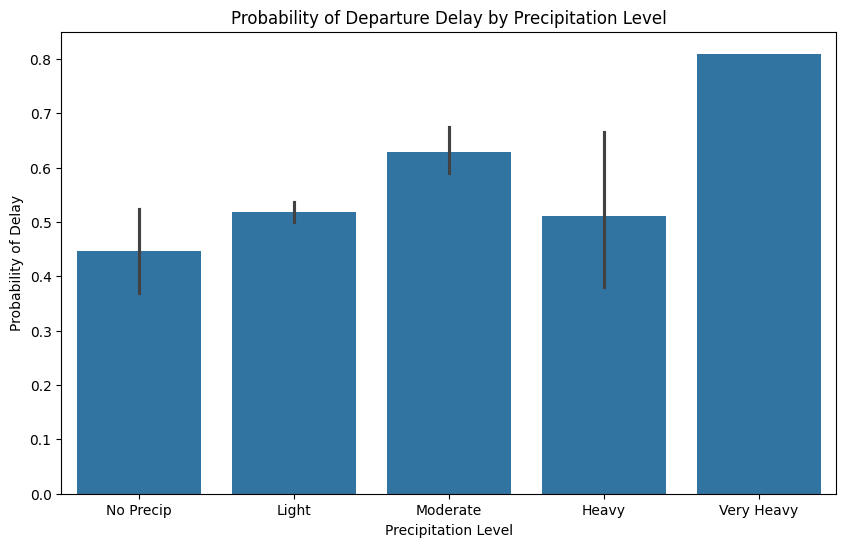

/tmp/ipykernel_1934/3033118394.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_speed_delay = flights_with_weather.groupby('wind_speed_bins')['is_delayed'].mean().reset_index()


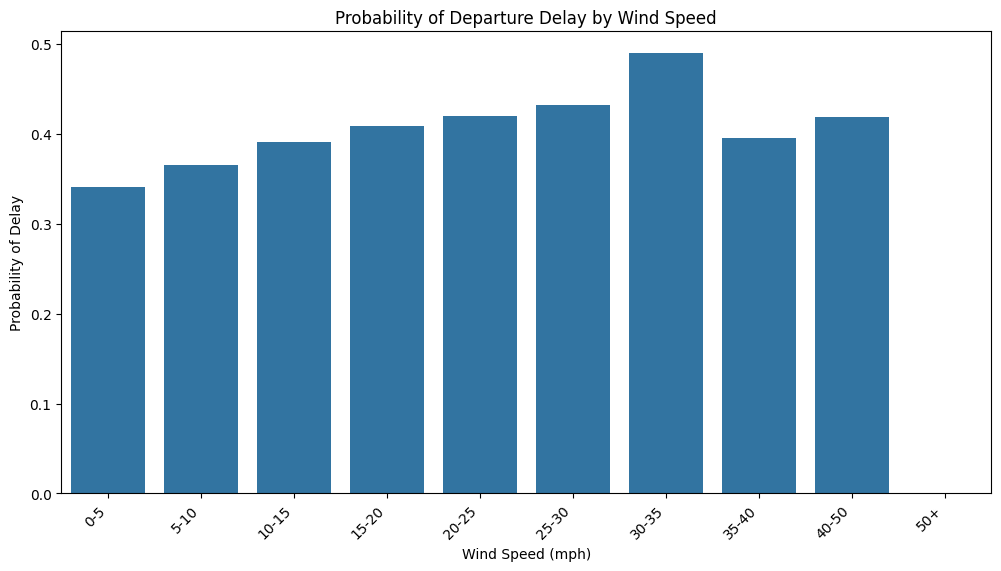

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a delay threshold
flights_with_weather['is_delayed'] = flights_with_weather['dep_delay'] > 0

# Analyze the effect of precipitation on delays
precip_delay = flights_with_weather.groupby('precip')['is_delayed'].mean().reset_index()
precip_delay['precip_category'] = pd.cut(precip_delay['precip'], bins=[-0.01, 0.01, 0.1, 0.5, 1, 100], labels=['No Precip', 'Light', 'Moderate', 'Heavy', 'Very Heavy'], right=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='precip_category', y='is_delayed', data=precip_delay.sort_values('precip_category'))
plt.title('Probability of Departure Delay by Precipitation Level')
plt.xlabel('Precipitation Level')
plt.ylabel('Probability of Delay')
plt.show()

# Analyze the effect of wind speed on delays
# Create wind speed bins for better visualization
flights_with_weather['wind_speed_bins'] = pd.cut(flights_with_weather['wind_speed'], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 100], labels=[f'{i}-{i+5}' for i in range(0, 40, 5)] + ['40-50', '50+'], right=False)
wind_speed_delay = flights_with_weather.groupby('wind_speed_bins')['is_delayed'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='wind_speed_bins', y='is_delayed', data=wind_speed_delay)
plt.title('Probability of Departure Delay by Wind Speed')
plt.xlabel('Wind Speed (mph)')
plt.ylabel('Probability of Delay')
plt.xticks(rotation=45, ha='right')
plt.show()

Continuing the analysis, let's look at the impact of visibility, temperature, and humidity on departure delays.

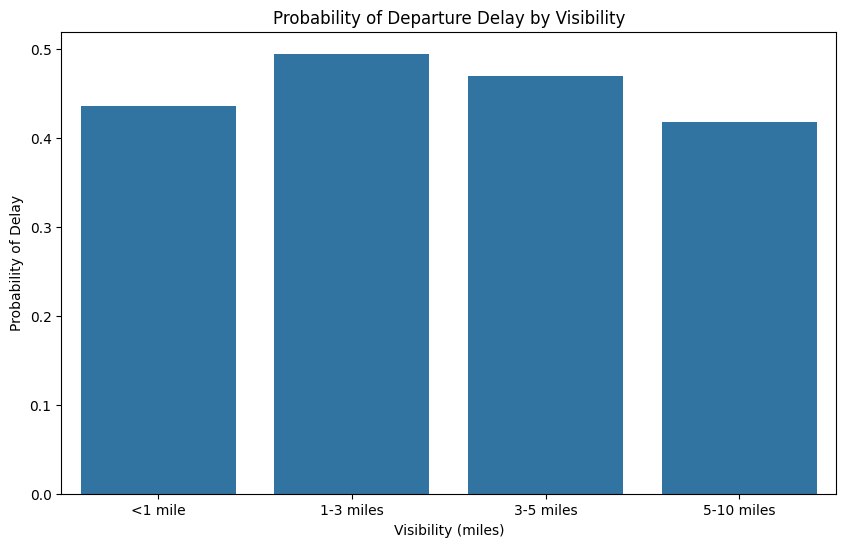

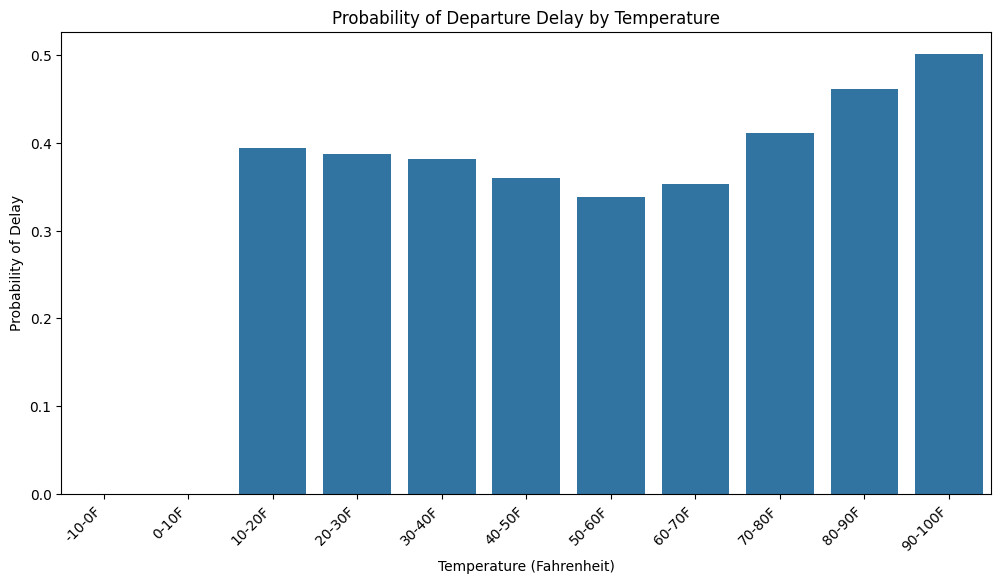

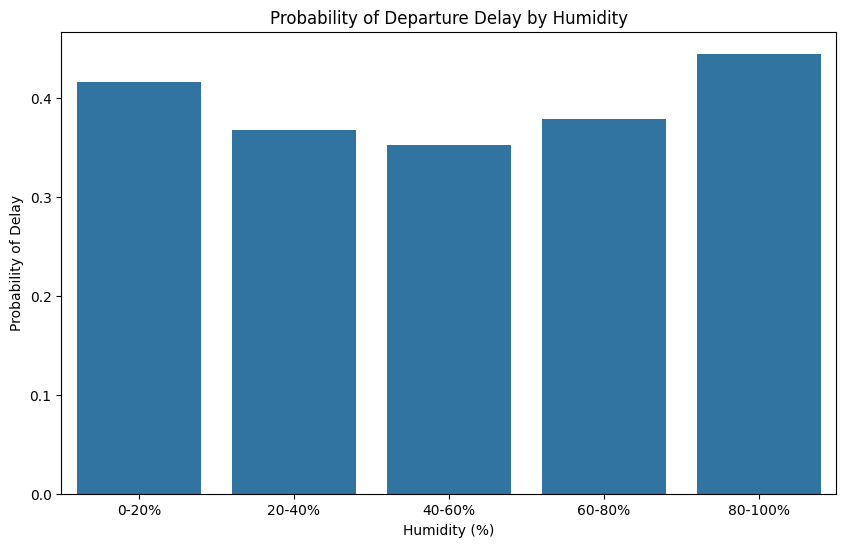

In [67]:
# Analyze the effect of visibility on delays
flights_with_weather['visib_bins'] = pd.cut(flights_with_weather['visib'], bins=[0, 1, 3, 5, 10], labels=['<1 mile', '1-3 miles', '3-5 miles', '5-10 miles'], right=False)
visib_delay = flights_with_weather.groupby('visib_bins', observed=False)['is_delayed'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='visib_bins', y='is_delayed', data=visib_delay)
plt.title('Probability of Departure Delay by Visibility')
plt.xlabel('Visibility (miles)')
plt.ylabel('Probability of Delay')
plt.show()

# Analyze the effect of temperature on delays
flights_with_weather['temp_bins'] = pd.cut(flights_with_weather['temp'], bins=[-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], labels=[f'{i}-{i+10}F' for i in range(-10, 100, 10)], right=False)
temp_delay = flights_with_weather.groupby('temp_bins', observed=False)['is_delayed'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='temp_bins', y='is_delayed', data=temp_delay)
plt.title('Probability of Departure Delay by Temperature')
plt.xlabel('Temperature (Fahrenheit)')
plt.ylabel('Probability of Delay')
plt.xticks(rotation=45, ha='right')
plt.show()

# Analyze the effect of humidity on delays
flights_with_weather['humid_bins'] = pd.cut(flights_with_weather['humid'], bins=[0, 20, 40, 60, 80, 100], labels=[f'{i}-{i+20}%' for i in range(0, 80, 20)] + ['80-100%'], right=False)
humid_delay = flights_with_weather.groupby('humid_bins', observed=False)['is_delayed'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='humid_bins', y='is_delayed', data=humid_delay)
plt.title('Probability of Departure Delay by Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Probability of Delay')
plt.show()

These plots now provide a more complete picture of how various weather conditions relate to departure delays. Low visibility, extreme temperatures (very cold or very hot), and very high humidity can all contribute to an increased probability of delays. Combining these insights with the earlier analysis of precipitation and wind speed gives a comprehensive understanding of weather-related flight disruptions.

These plots provide initial insights into how precipitation and wind speed relate to departure delays. Generally, higher precipitation and wind speeds tend to increase the probability of delays. We can perform similar analyses for other weather variables like `visibility`, `temperature`, and `humidity` to get a more comprehensive picture.